In [20]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
pip install catboost

Bước 1: đọc file đưa vào dataframe

In [22]:
import pandas as pd
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score, KFold, StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, RandomForestClassifier



from sklearn.neural_network import MLPClassifier

from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import confusion_matrix
from sklearn.tree import export_graphviz

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer

from catboost import CatBoostClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score

import datetime
import xgboost as xgb


import numpy as np
import time
import datetime
import pydot
import os
import sys
import seaborn as sns
import matplotlib.pyplot as plt



# ĐỌC FILE BAN ĐẦU CHƯA CHUẨN HÓA
df = pd.read_csv('/content/drive/MyDrive/Năm 4/khoa luan/DU DOAN UNG THU PHOI/Lung Cancer Dataset.csv')

#in dữ liệu sau khi đọc từ file
print(df)

      AGE  GENDER  SMOKING  FINGER_DISCOLORATION  MENTAL_STRESS  \
0      68       1        1                     1              1   
1      81       1        1                     0              0   
2      58       1        1                     0              0   
3      44       0        1                     0              1   
4      72       0        1                     1              1   
...   ...     ...      ...                   ...            ...   
4995   32       0        1                     1              0   
4996   80       0        1                     1              1   
4997   51       1        0                     0              1   
4998   76       1        0                     1              0   
4999   33       0        1                     0              0   

      EXPOSURE_TO_POLLUTION  LONG_TERM_ILLNESS  ENERGY_LEVEL  IMMUNE_WEAKNESS  \
0                         1                  0     57.831178                0   
1                         1      

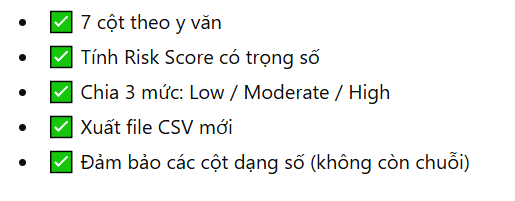

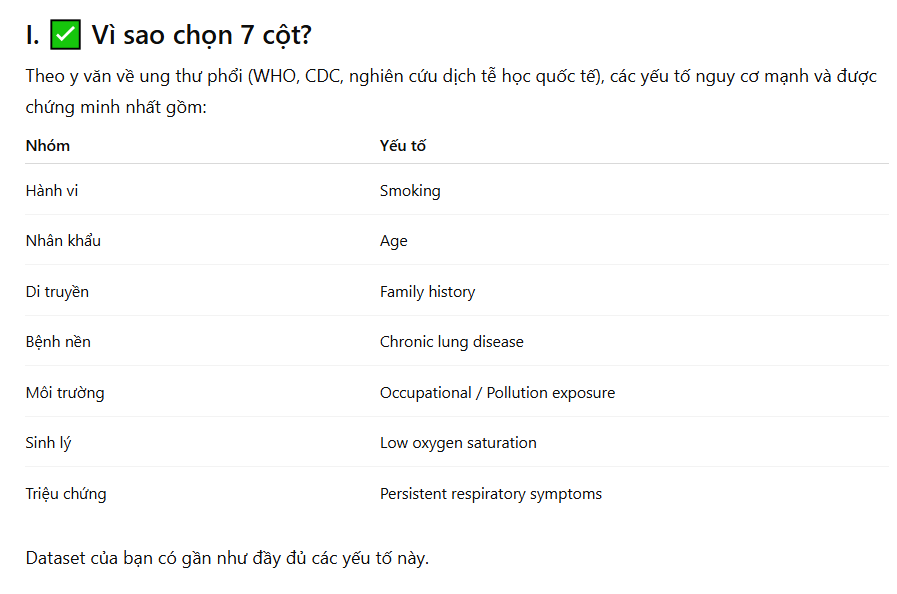

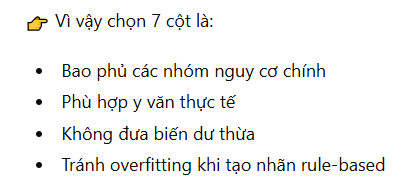

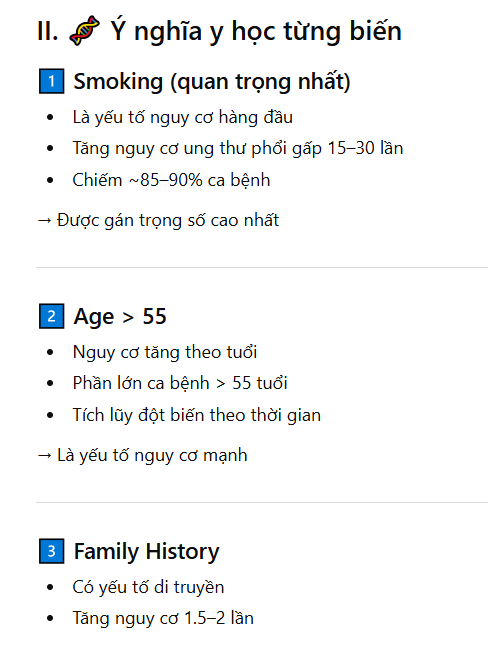

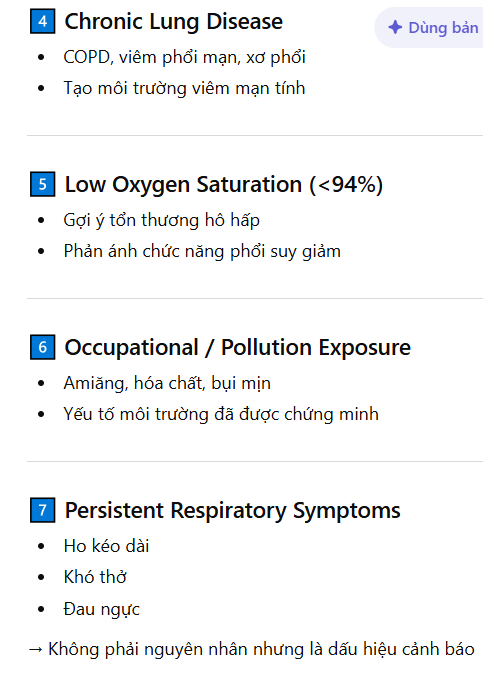

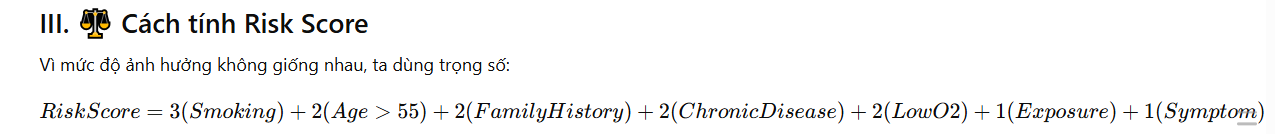

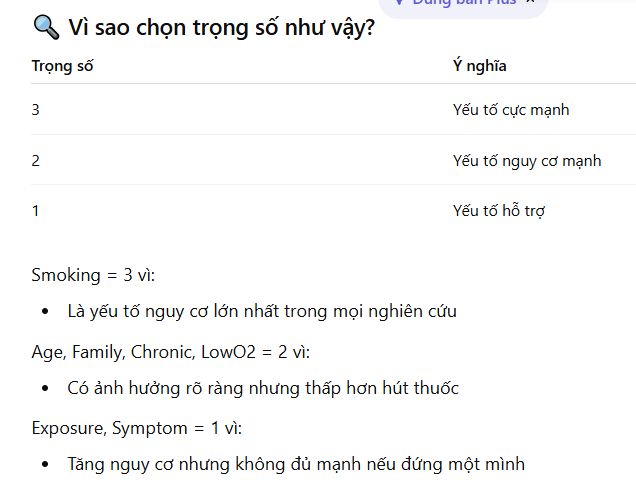

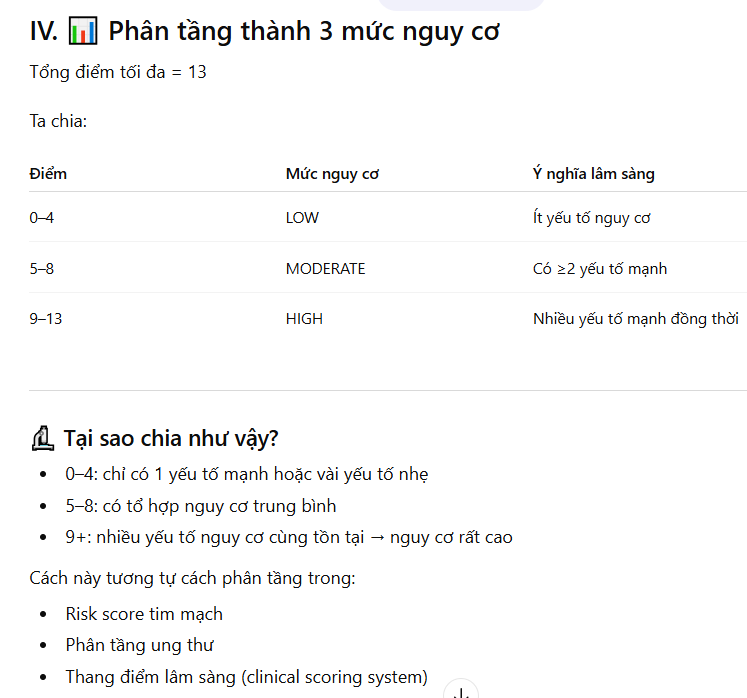

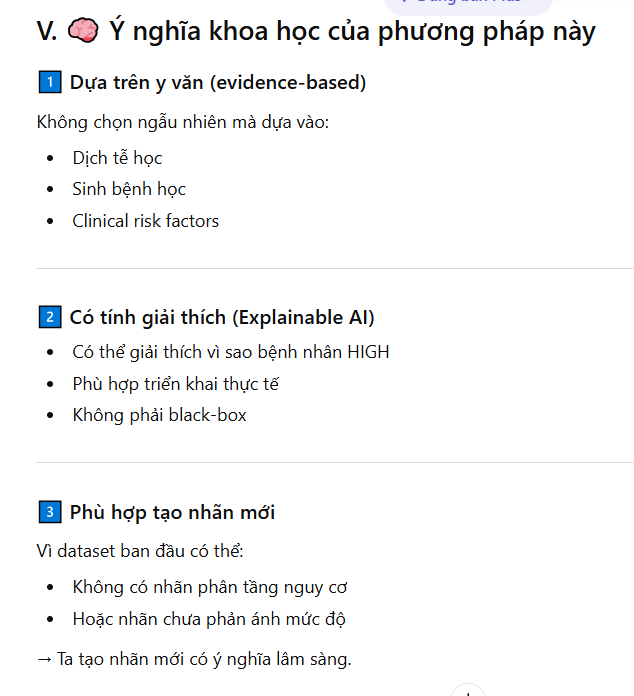

Đã tạo xong dataset mới: Lung_Cancer_Risk_3Levels.csv

Phân bố mức nguy cơ:
  Risk Level  Count  Percentage (%)
0   Moderate   1669           56.33
1        Low    889           30.00
2       High    405           13.67


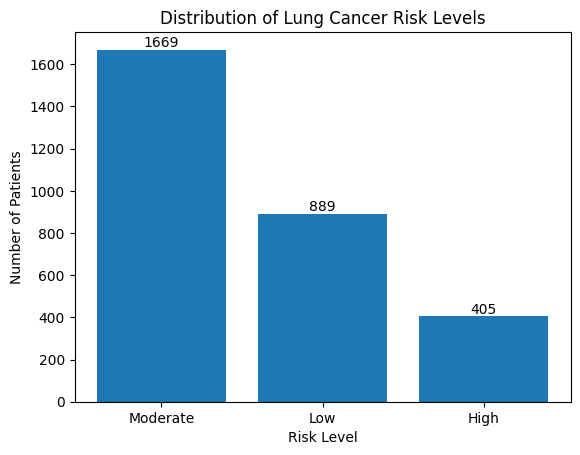

In [23]:
# ==========================================================
# TẠO DATASET NGUY CƠ UNG THƯ PHỔI (3 MỨC: LOW/MODERATE/HIGH)
# ==========================================================

import pandas as pd
import numpy as np

# ===============================
# 1️⃣ ĐỌC FILE
# ===============================


# ===============================
# 2️⃣ CHUẨN HÓA CỘT NHÃN YES/NO
# ===============================
df['PULMONARY_DISEASE'] = df['PULMONARY_DISEASE'].map({
    'YES': 1,
    'NO': 0
})

# ===============================
# 3️⃣ CHỈ GIỮ NGƯỜI KHÔNG BỊ UNG THƯ
# ===============================
df_no_cancer = df[df['PULMONARY_DISEASE'] == 0].copy()

# ===============================
# 4️⃣ TẠO CÁC BIẾN NGUY CƠ (7 CỘT)
# ===============================

# Age > 55
df_no_cancer['AGE_RISK'] = np.where(df_no_cancer['AGE'] > 55, 1, 0)

# Smoking
df_no_cancer['SMOKING_RISK'] = df_no_cancer['SMOKING']

# Family History
df_no_cancer['FAMILY_HISTORY_RISK'] = df_no_cancer['FAMILY_HISTORY']

# Chronic Lung Disease
df_no_cancer['CHRONIC_DISEASE_RISK'] = df_no_cancer['LONG_TERM_ILLNESS']

# Low Oxygen (<94)
df_no_cancer['LOW_OXYGEN_RISK'] = np.where(
    df_no_cancer['OXYGEN_SATURATION'] < 94, 1, 0
)

# Pollution Exposure
df_no_cancer['EXPOSURE_RISK'] = df_no_cancer['EXPOSURE_TO_POLLUTION']

# Persistent Respiratory Symptoms
df_no_cancer['SYMPTOM_RISK'] = (
    df_no_cancer['BREATHING_ISSUE'] +
    df_no_cancer['CHEST_TIGHTNESS'] +
    df_no_cancer['THROAT_DISCOMFORT']
)

df_no_cancer['SYMPTOM_RISK'] = np.where(
    df_no_cancer['SYMPTOM_RISK'] >= 1, 1, 0
)

# ===============================
# 5️⃣ TÍNH RISK SCORE (CÓ TRỌNG SỐ)
# ===============================

df_no_cancer['RISK_SCORE'] = (
    3 * df_no_cancer['SMOKING_RISK'] +
    2 * df_no_cancer['AGE_RISK'] +
    2 * df_no_cancer['FAMILY_HISTORY_RISK'] +
    2 * df_no_cancer['CHRONIC_DISEASE_RISK'] +
    2 * df_no_cancer['LOW_OXYGEN_RISK'] +
    1 * df_no_cancer['EXPOSURE_RISK'] +
    1 * df_no_cancer['SYMPTOM_RISK']
)

# ===============================
# 6️⃣ PHÂN TẦNG 3 MỨC
# ===============================

def classify_risk(score):
    if score <= 4:
        return "Low"
    elif score <= 8:
        return "Moderate"
    else:
        return "High"

df_no_cancer['RISK_LEVEL'] = df_no_cancer['RISK_SCORE'].apply(classify_risk)

# ===============================
# 7️⃣ TẠO DATASET MỚI CHỈ GIỮ 7 CỘT + NHÃN
# ===============================

df_risk_dataset = df_no_cancer[[
    'AGE_RISK',
    'SMOKING_RISK',
    'FAMILY_HISTORY_RISK',
    'CHRONIC_DISEASE_RISK',
    'LOW_OXYGEN_RISK',
    'EXPOSURE_RISK',
    'SYMPTOM_RISK',
    'RISK_SCORE',
    'RISK_LEVEL'
]]

# ===============================
# 8️⃣ LƯU FILE MỚI
# ===============================
df_risk_dataset.to_csv("/content/drive/MyDrive/Năm 4/khoa luan/DU DOAN UNG THU PHOI/1.6.TaoNhanMoi/Lung_Cancer_Risk_3Levels.csv", index=False)
print("Đã tạo xong dataset mới: Lung_Cancer_Risk_3Levels.csv")

# ===============================
# 9️⃣ THỐNG KÊ RISK LEVEL
# ===============================
risk_counts = df_risk_dataset['RISK_LEVEL'].value_counts()
total = len(df_risk_dataset)

print("\nPhân bố mức nguy cơ:")

result_table = pd.DataFrame({
    'Risk Level': risk_counts.index,
    'Count': risk_counts.values,
    'Percentage (%)': (risk_counts.values / total) * 100
})

result_table['Percentage (%)'] = result_table['Percentage (%)'].round(2)
print(result_table)

# ===============================
# 🔟 VẼ BIỂU ĐỒ
# ===============================

plt.figure()

bars = plt.bar(risk_counts.index, risk_counts.values)

plt.title("Distribution of Lung Cancer Risk Levels")
plt.xlabel("Risk Level")
plt.ylabel("Number of Patients")

plt.xticks(rotation=0)

# Chỉ ghi số lượng lên đầu cột
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        int(height),
        ha='center',
        va='bottom'
    )

# Lưu biểu đồ
plt.savefig("/content/drive/MyDrive/Năm 4/khoa luan/DU DOAN UNG THU PHOI/1.6.TaoNhanMoi/Risk_Level_BarChart.png", dpi=300, bbox_inches='tight')
plt.show()